## WE Telecom Egypt — Package Recommender System

### Notebook Description
---

This notebook includes:

- Data Loading – Import the dataset.
- Data Wrangling – Clean and prepare the data.
- Exploratory Data Analysis (EDA) – Explore patterns and relationships.
- Preprocessing & Encoding – Prepare features for modeling.
- Model Building – Train and evaluate models.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

---
Load Data

In [ ]:
df = pd.read_csv('data\WE_Dataset.csv')
df.shape

(50000, 19)

Show Random Rows of Dataset

In [3]:
df.sample(7)

,user_id,governorate,governorate_code,current_package_id,current_package_size_gb,current_package_price,current_speed_mbps,number_of_devices,device_group,renewal_date,days_passed,days_until_renewal,usage_so_far_gb,remaining_gb,projected_usage_gb,actual_speed_mbps,user_profile,recommended_package_id,is_change
21095,20884539,Giza,2,STD-1111-250,250,360,30,8,large (5-9),2026-04-22,25,5,262.50,0.00,315.00,10.61,heavy,STD-1111-400,1
14745,29126111,Cairo,2,STD-1111-200,200,290,30,2,small (1-4),2026-04-18,29,1,209.05,0.00,216.26,21.21,over,STD-2222-250,1
44344,55274717,Sharqia,55,STD-3333-600,600,1230,100,5,large (5-9),2026-04-28,19,11,457.71,142.29,722.70,44.72,heavy,STD-2222-1000,1
22782,28509987,Cairo,2,STD-1111-140,140,210,30,3,small (1-4),2026-05-06,11,19,73.37,66.63,200.10,17.32,over,STD-2222-250,1
5986,37079606,Alexandria,3,STD-2222-250,250,530,70,5,large (5-9),2026-05-13,4,26,7.53,242.47,56.48,31.30,casual,STD-1111-140,1
45679,20815088,Giza,2,STD-2222-250,250,530,70,5,large (5-9),2026-04-29,18,12,262.50,0.00,437.50,31.30,over,STD-2222-600,1
2805,32398474,Alexandria,3,STD-1111-140,140,210,30,1,small (1-4),2026-04-18,29,1,94.66,45.34,97.92,30.00,heavy,STD-1111-140,0


---
### Data Wrangling
- Missing values
- Data types
- Logical constraints 
- Duplicates
- Outliers

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  50000 non-null  int64  
 1   governorate              50000 non-null  object 
 2   governorate_code         50000 non-null  int64  
 3   current_package_id       50000 non-null  object 
 4   current_package_size_gb  50000 non-null  int64  
 5   current_package_price    50000 non-null  int64  
 6   current_speed_mbps       50000 non-null  int64  
 7   number_of_devices        50000 non-null  int64  
 8   device_group             50000 non-null  object 
 9   renewal_date             50000 non-null  object 
 10  days_passed              50000 non-null  int64  
 11  days_until_renewal       50000 non-null  int64  
 12  usage_so_far_gb          50000 non-null  float64
 13  remaining_gb             50000 non-null  float64
 14  projected_usage_gb    

Check for missing values

In [5]:
df.isnull().sum().sum()

0

Note:
- No missing values found

---
Check Logical Constraints

In [6]:
checks = [
    (df['remaining_gb'] >= 0).all(),
    (df['usage_so_far_gb'] >= 0).all(),
    (df['projected_usage_gb'] > 0).all(),
    (df['actual_speed_mbps'] > 0).all(),
    df['number_of_devices'].between(1, 9).all(),
    df['days_passed'].between(1, 29).all(),
    df['days_until_renewal'].between(1, 29).all(),
    (df['days_passed'] + df['days_until_renewal'] == 30).all()
]
print("No problems" if all(checks) else "Problem found")

No problems


---
Check for Duplicated data


In [7]:
dup_rows = df.duplicated().sum()
dup_ids  = df['user_id'].duplicated().sum()
print(f'Duplicate rows:    {dup_rows}')
print(f'Duplicate user_ids: {dup_ids}')

Duplicate rows:    0
Duplicate user_ids: 0


Note:
- there is no duplicate data.

---
Statistical Summary

In [8]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
user_id,50000.0,49545263.97,23460828.38,20000796.00,28392109.00,45800466.50,64855497.75,97998583.00
governorate_code,50000.0,38.55,33.86,2.00,2.00,45.00,64.00,97.00
current_package_size_gb,50000.0,476.92,309.37,140.00,250.00,250.00,600.00,1000.00
current_package_price,50000.0,863.90,527.11,210.00,530.00,700.00,1230.00,2000.00
current_speed_mbps,50000.0,89.02,85.77,30.00,30.00,70.00,100.00,500.00
number_of_devices,50000.0,4.01,2.02,1.00,2.00,4.00,5.00,9.00
days_passed,50000.0,14.97,8.37,1.00,8.00,15.00,22.00,29.00
days_until_renewal,50000.0,15.03,8.37,1.00,8.00,15.00,22.00,29.00
usage_so_far_gb,50000.0,254.69,259.97,0.69,68.93,161.30,335.74,1050.00
remaining_gb,50000.0,225.74,228.20,0.00,62.62,157.18,318.26,994.24


In [9]:
selected_columns = [
    "usage_so_far_gb",
    "projected_usage_gb",
    "actual_speed_mbps"]

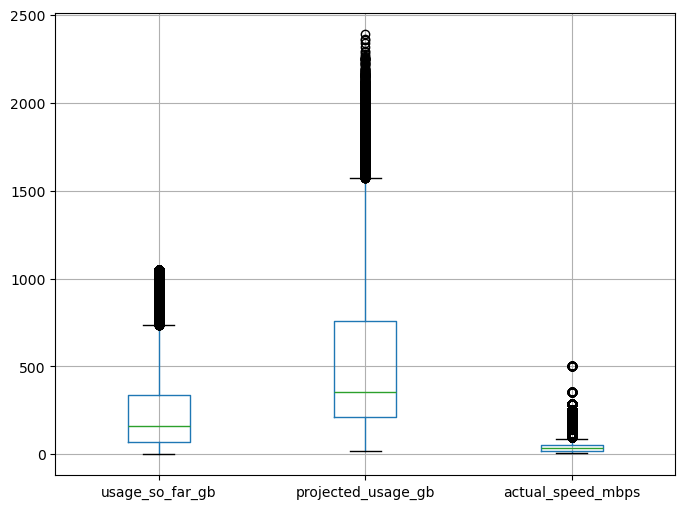

In [10]:
plt.figure(figsize=(8, 6))

df[selected_columns].boxplot()
plt.show()

Outlier Detection

In [ ]:
def handle_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 -1.5*IQR
    upper_bound = Q3 +1.5*IQR
    df[column] = df[column].where(df[column] >= lower_bound, lower_bound)
    df[column] = df[column].where(df[column] <= upper_bound, upper_bound)
    return df

for col in selected_columns:
    df = handle_outliers(df, col)

---
### EDA — Exploratory Data Analysis

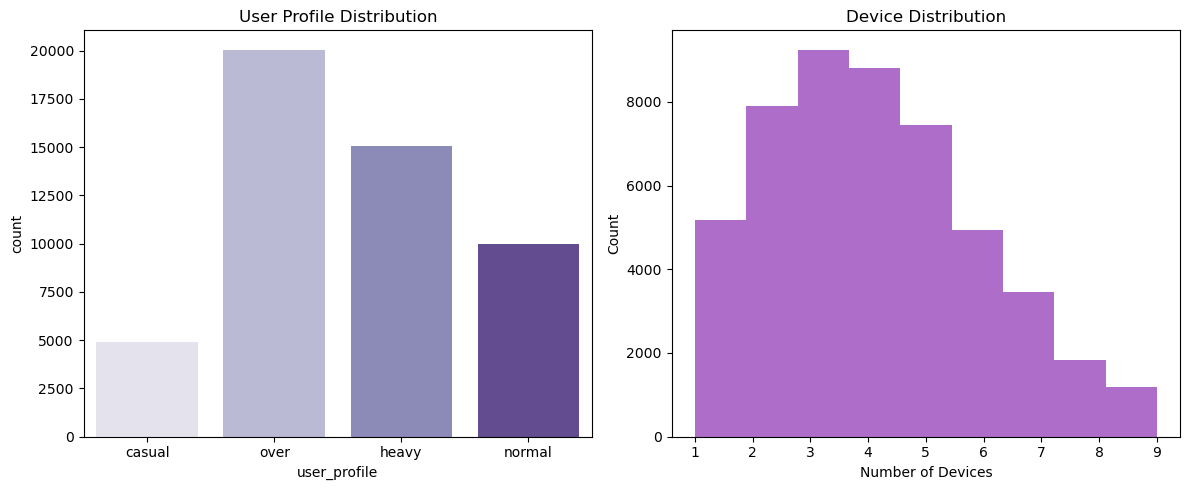

In [12]:
plt.figure(figsize=(12,5))

# User Profile 
plt.subplot(1, 2, 1)
sns.countplot(x="user_profile", data=df, palette="Purples")
plt.title("User Profile Distribution")

# Number of Devices
plt.subplot(1, 2, 2)
plt.hist(df["number_of_devices"], bins=9, color= '#AF6DCA')
plt.title("Device Distribution")
plt.xlabel("Number of Devices")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

**User Profile Distribution**

- "Over" is the largest segment (~20K), followed by Heavy (~15K) and Normal (~10K)
Casual users are the smallest group (~5K) — likely low-value customers

**Device Distribution**

- Most customers own 3–5 devices, peaking around 4
Very few customers have 8–9 devices

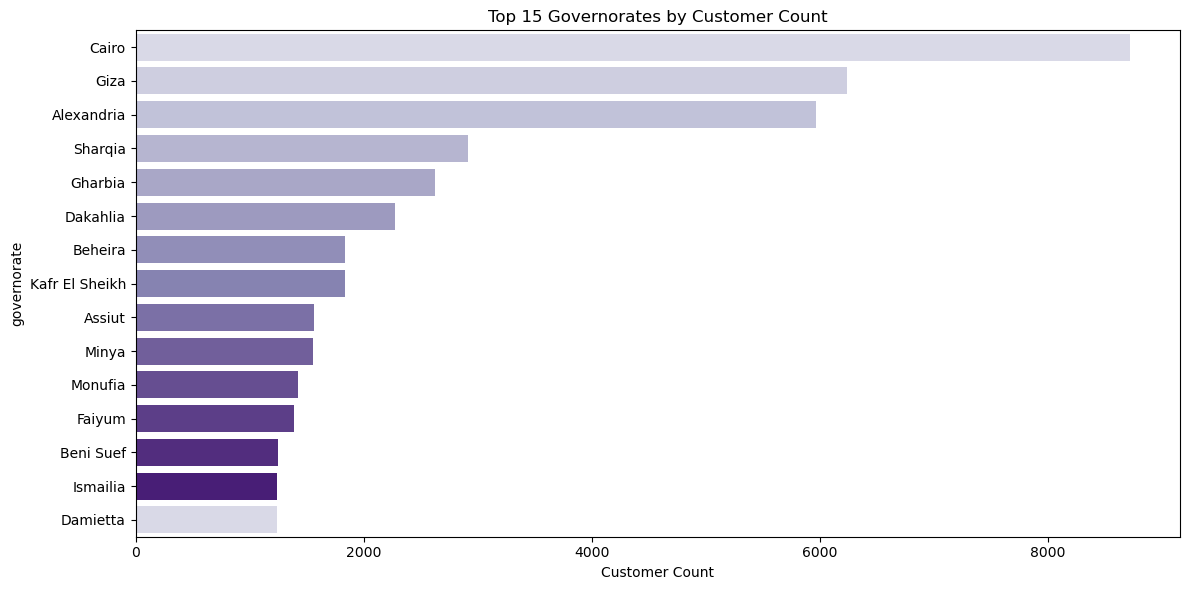

In [13]:
gov_counts = df['governorate'].value_counts().head(15)

plt.figure(figsize=(12,6))
sns.barplot(x=gov_counts.values, y=gov_counts.index, palette=sns.color_palette("Purples", len(gov_counts) + 3)[4:])

plt.title("Top 15 Governorates by Customer Count")
plt.xlabel("Customer Count")

plt.tight_layout()
plt.show()

Top 15 Governorates by Customer Count

- Cairo leads by far, followed by Giza and Alexandria
- Urban governorates dominate — rural areas have significantly lower penetration

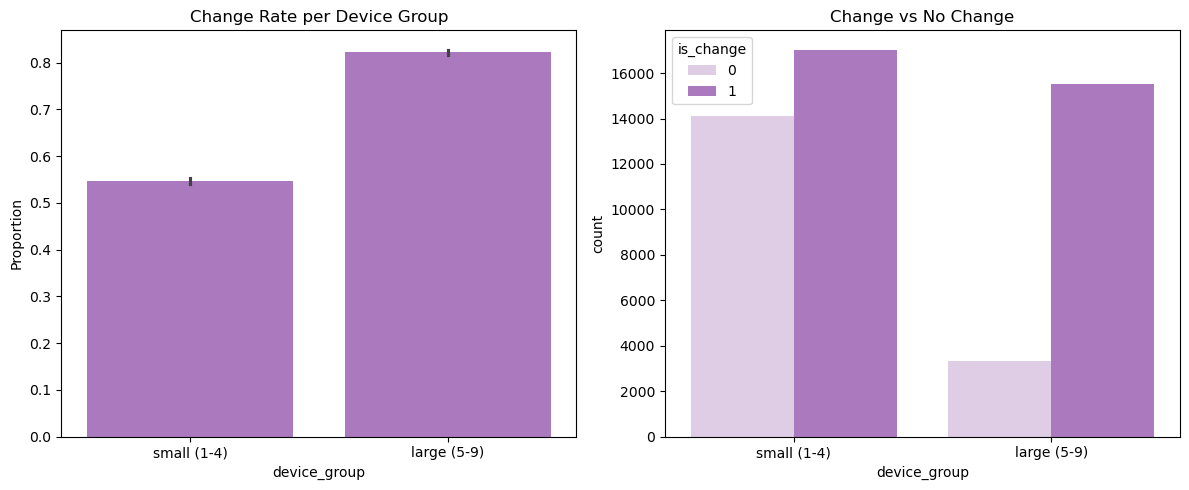

In [14]:
plt.figure(figsize=(12,5))

# Change rate
plt.subplot(1, 2, 1)
sns.barplot(
    x="device_group",
    y="is_change",
    data=df,
    color='#AF6DCA'
)
plt.title("Change Rate per Device Group")
plt.ylabel("Proportion")

# Change vs No Change
plt.subplot(1, 2, 2)
sns.countplot(
    x="device_group",
    hue="is_change",
    data=df,
    palette=["#e0c9e9", "#AF6DCA"]
)
plt.title("Change vs No Change")

plt.tight_layout()
plt.show()

**Change Rate per Device Group & Change vs No Change**

- Large device group customers switch plans at a much higher rate (~80%) vs small (~60%)
- Large device group shows more active changers in absolute numbers

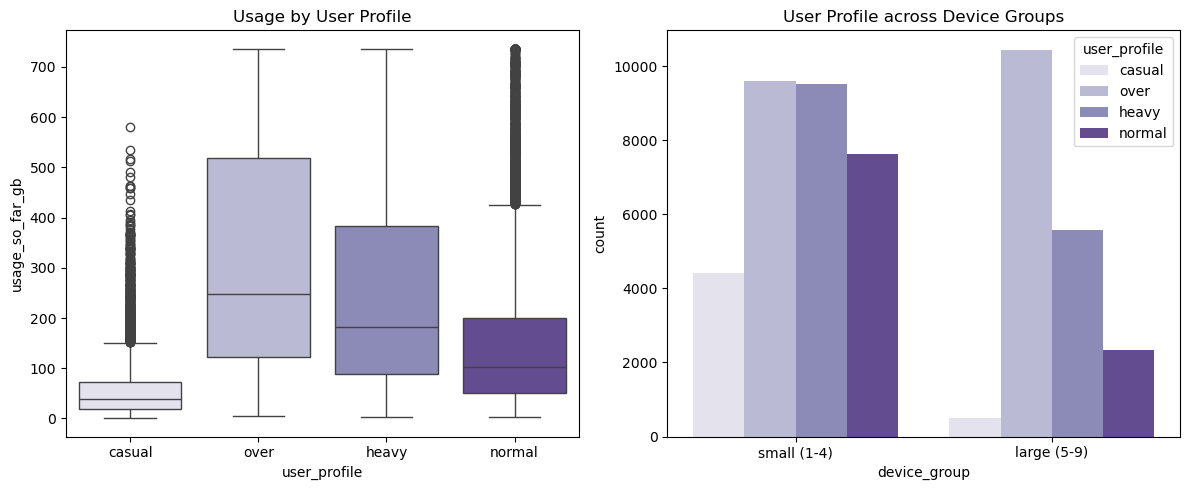

In [15]:
plt.figure(figsize=(12,5))

# Usage by profile
plt.subplot(1, 2, 1)
sns.boxplot(
    x="user_profile",
    y="usage_so_far_gb",
    data=df,
    palette="Purples"
)
plt.title("Usage by User Profile")

# Profile across device groups
plt.subplot(1, 2, 2)
sns.countplot(
    x="device_group",
    hue="user_profile",
    data=df,
    palette="Purples"
)
plt.title("User Profile across Device Groups")

plt.tight_layout()
plt.show()

Usage by User Profile 

- Heavy users have the highest and most variable data usage with many outliers reaching 700+
- Casual users consume the least data with a tight, low distribution
- Over users show moderate-high usage with notable spread

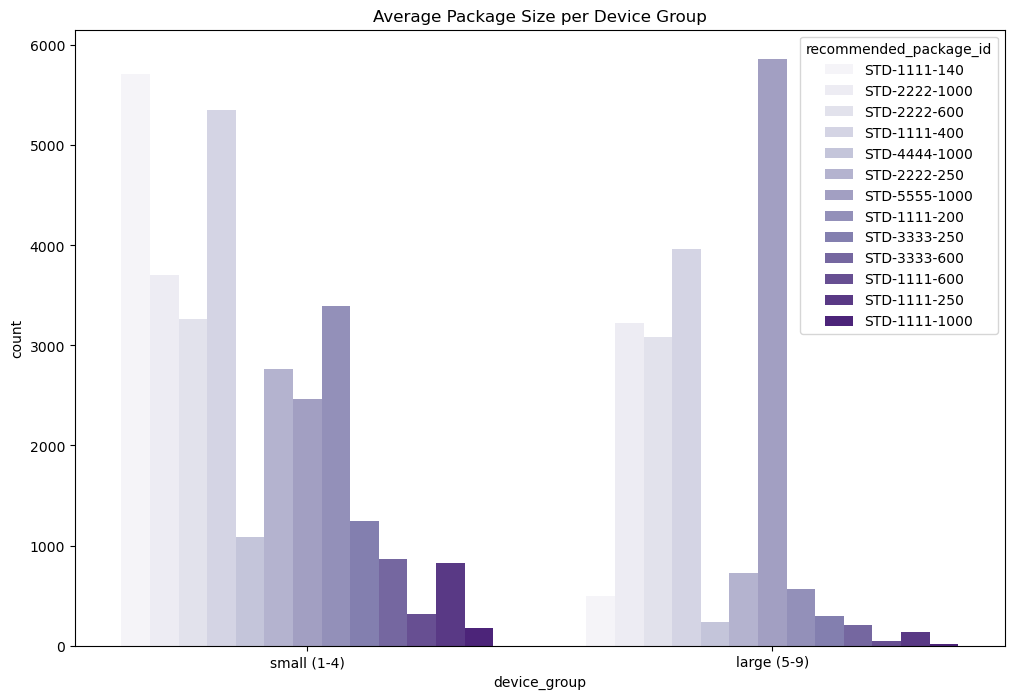

In [16]:
plt.figure(figsize=(12,8))

sns.countplot(
    x="device_group",
    hue="recommended_package_id",
    data=df,
    palette="Purples"
)

plt.title("Average Package Size per Device Group")
plt.show()

Average Package Size per Device Group

- STD-1111-140 and STD-1111-400 are the top recommended packages for small devices
- Smaller/cheaper packages dominate recommendations across both groups

How many users are actually in danger of exceeding their package

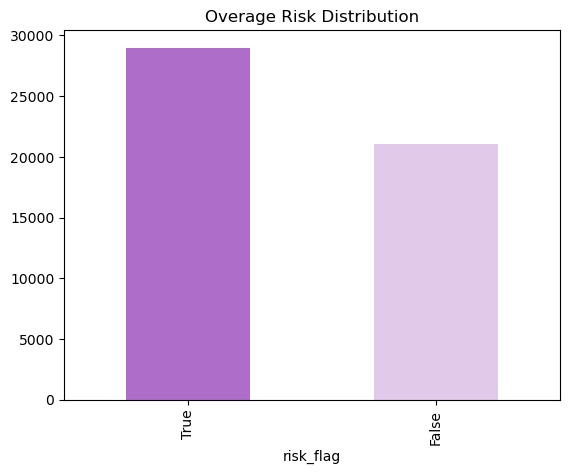

In [17]:
df['risk_flag'] = (df['projected_usage_gb'] > df['current_package_size_gb'])

df['risk_flag'].value_counts().plot(kind='bar', color=['#AF6DCA', '#e0c9e9'])
plt.title("Overage Risk Distribution")
plt.show()

Overage Risk Distribution

- The majority of customers (~28K) are flagged as overage risk = True
- Only ~21K are flagged False — meaning most customers are at risk of exceeding their plan

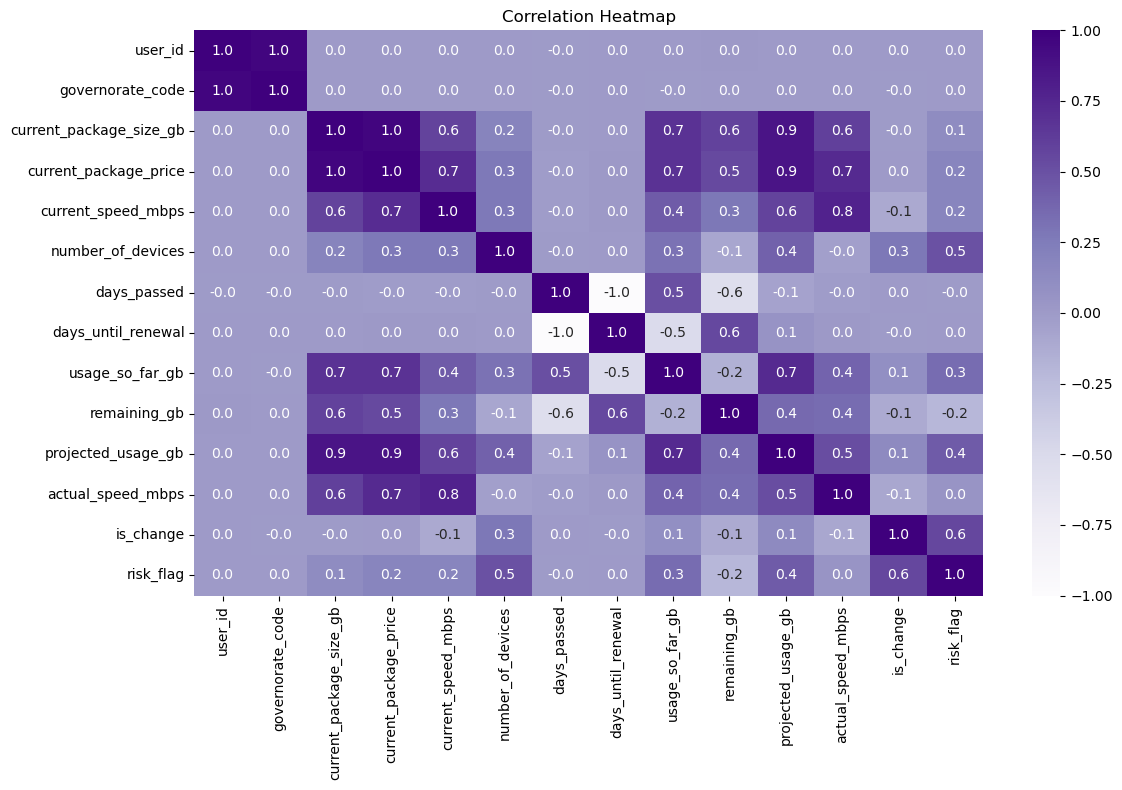

In [18]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,
    cmap="Purples",
    fmt=".1f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

---
##### Feature Engineering 

In [19]:
df_model = df.copy()

# Engineered features
df_model['usage_efficiency']  = df_model['usage_so_far_gb'] / df_model['current_package_size_gb']
df_model['days_to_finish']    = df_model['remaining_gb'] / (df_model['projected_usage_gb'] / 30).clip(lower=0.1)
df_model['overage_risk']      = (df_model['projected_usage_gb'] > df_model['current_package_size_gb']).astype(int)
df_model['price_per_gb']      = df_model['current_package_price'] / df_model['current_package_size_gb']
df_model['projected_vs_pkg']  = df_model['projected_usage_gb'] / df_model['current_package_size_gb']
df_model['speed_per_device']  = df_model['actual_speed_mbps'] / df_model['number_of_devices']

---
##### Encodding


In [22]:
# Encode Target 
target_le = LabelEncoder()
df_model['target_encoded'] = target_le.fit_transform(df_model['recommended_package_id'])

In [23]:
# Label encode current_package_id
pkg_le = LabelEncoder()
df_model['current_package_id'] = pkg_le.fit_transform(df_model['current_package_id'])

# Drop columns NOT for model 
DROP_COLS = [
    'user_id', 'renewal_date', 'governorate_code',
    'user_profile', 'device_group', 'is_change',
    'recommended_package_id', 'risk_flag',
    'target_encoded',
    'projected_usage_gb',   
    'days_to_finish',       
    'projected_vs_pkg',     
    'overage_risk',         
    'governorate',          
]
feature_cols = [c for c in df_model.columns if c not in DROP_COLS]

Train/Test Split

In [ ]:
X = df_model[feature_cols]
y = df_model['target_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print(f'Train size: {len(X_train)}')
print(f'Test size: {len(X_test)}')

Train size: 40000
Test size: 10000


---
##### Model Training — XGBoost

In [ ]:
model = XGBClassifier(
    n_estimators=1000,
    max_depth=9,           
    learning_rate=0.03,    
    subsample=0.9,
    random_state=42,
    early_stopping_rounds=30,
)
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)
print("Best iteration:", model.best_iteration)

[0]	validation_0-mlogloss:2.40162
[50]	validation_0-mlogloss:0.77541
[100]	validation_0-mlogloss:0.42712
[150]	validation_0-mlogloss:0.28546
[200]	validation_0-mlogloss:0.21355
[250]	validation_0-mlogloss:0.17031
[300]	validation_0-mlogloss:0.14286
[350]	validation_0-mlogloss:0.12458
[400]	validation_0-mlogloss:0.11222
[450]	validation_0-mlogloss:0.10362
[500]	validation_0-mlogloss:0.09718
[550]	validation_0-mlogloss:0.09259
[600]	validation_0-mlogloss:0.08894
[650]	validation_0-mlogloss:0.08601
[700]	validation_0-mlogloss:0.08381
[750]	validation_0-mlogloss:0.08211
[800]	validation_0-mlogloss:0.08061
[850]	validation_0-mlogloss:0.07955
[900]	validation_0-mlogloss:0.07857
[950]	validation_0-mlogloss:0.07768
[999]	validation_0-mlogloss:0.07696
Best iteration: 999


In [26]:
# Evaluation 
y_pred = model.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print(f'Test Accuracy: {acc*100:.2f}%')
print('Classification Report:')
print(classification_report(
    y_test, y_pred,
    target_names=target_le.classes_,
    zero_division=0))

Test Accuracy: 97.55%
Classification Report:
               precision    recall  f1-score   support

STD-1111-1000       0.86      0.97      0.91        38
 STD-1111-140       0.99      0.99      0.99      1241
 STD-1111-200       0.95      0.97      0.96       791
 STD-1111-250       0.98      0.96      0.97       193
 STD-1111-400       0.98      0.99      0.98      1861
 STD-1111-600       0.93      0.89      0.91        71
STD-2222-1000       0.97      0.97      0.97      1385
 STD-2222-250       0.97      0.95      0.96       699
 STD-2222-600       0.97      0.96      0.97      1270
 STD-3333-250       0.98      0.98      0.98       308
 STD-3333-600       0.94      0.94      0.94       213
STD-4444-1000       0.96      0.97      0.96       264
STD-5555-1000       0.99      0.99      0.99      1666

     accuracy                           0.98     10000
    macro avg       0.96      0.96      0.96     10000
 weighted avg       0.98      0.98      0.98     10000



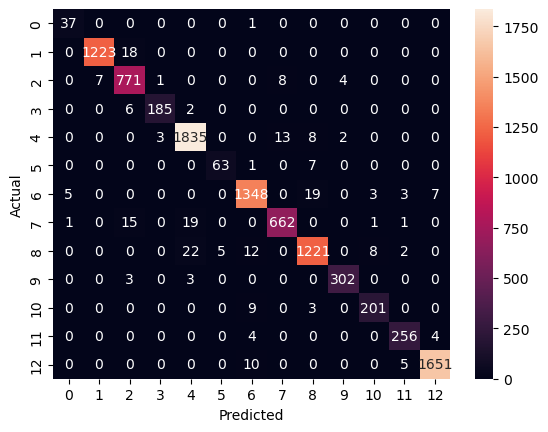

In [27]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

---
#### Summary & Insights

In [29]:
print('='*60)
print('WE Package Recommender — Project Summary')
print('='*60)
print(f'Dataset:         {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Model:           XGBoost (best_iter={model.best_iteration})')
print(f'Test Accuracy:   {acc*100:.2f}%')
print(f'Features Used:   {len(feature_cols)} (after Encoding)')

WE Package Recommender — Project Summary
Dataset:         50,000 rows × 20 columns
Model:           XGBoost (best_iter=999)
Test Accuracy:   97.55%
Features Used:   13 (after Encoding)


In [34]:
import joblib
import os

SAVE_DIR = '.'  
os.makedirs(SAVE_DIR, exist_ok=True)

joblib.dump(model,        os.path.join(SAVE_DIR, 'we_model.pkl'))
joblib.dump(target_le,    os.path.join(SAVE_DIR, 'we_target_le.pkl'))
joblib.dump(pkg_le,       os.path.join(SAVE_DIR, 'we_pkg_le.pkl'))
joblib.dump(feature_cols, os.path.join(SAVE_DIR, 'we_feature_cols.pkl'))

['.\\we_feature_cols.pkl']